In [ ]:
#LLM 종류별 성능평가.

1. 환경설정
- 데이터셋 불러오기 : tool_execution_test_Dataset/test_dataset_cleaned.csv 사용
- 프롬프트 준비 : tool_node에서 사용할 SYSTEM_PROMPT 준비.
- LLM API KEY 준비 : .env에 작성되어있는 Gemini. Claude, OpenAI 키 준비.
- LangGraph 준비 : `1. tool_execution_test_Dataset_Generation.ipynb`의 `2.ToolNode` 부분에 나와있는 Graph 준비. 실제 Tool Call은 없이 llm_with_tools를 사용하는 Tool Node만 사용.


2. 평가 실행
데이터셋 `content`칼럼을 1행씩 graph에 넣고 실행. 최종 결과는 model_evaluation_result.csv에 `모델명_tool_called`, `모델명_tool_name`, `모델명_query`로 저장. 10행 실행시마다 처리 내용을 저장하는 백업 기능 구현.
위 평가를 지정한 전체 LLM 모델 별로 진행.
모델 : gpt-4o-mini, gpt-4o, gpt-5, gemini-3.1-pro-preview, gemini-3.5-flash, gemini-3-flash-preview, claude-opus-4-7, claude-sonnet-4-6, claude-haiku-4-5-20251001
temperature = 0

3. 시각화
데이터셋과 평가 결과 대조하여 결과 시각화.
LLM별 tool_called, tool_name 성능지표 : accuracy, recall, f1-score
LLM별 query 품질볖가 : LLM-as-a-Judge (gpt-4o). 테스트 데이터셋 context와 정답 query, 모델별 query를 대조해 1~5점으로 점수 작성. 점수별 기준 구체적으로 작성.


In [2]:
!pip install langchain-openai langchain-anthropic langchain-google-genai langchain-community langchain-tavily tavily-python arxiv python-dotenv scikit-learn matplotlib seaborn pandas langgraph -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os, json, time
import pandas as pd
import numpy as np
from pathlib import Path
from typing import Annotated, TypedDict, List

from dotenv import dotenv_values
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langchain_anthropic import ChatAnthropic
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_tavily import TavilySearch
from langchain.tools import tool
import arxiv

from sklearn.metrics import accuracy_score, recall_score, f1_score
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

matplotlib.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# ── API 키 로드 ────────────────────────────────────────────────────────────────
config = dotenv_values('./.env')
os.environ['OPENAI_API_KEY']    = config.get('OPENAI_API_KEY',    '').strip()
os.environ['TAVILY_API_KEY']    = config.get('TAVILY_API_KEY',    '').strip()
os.environ['ANTHROPIC_API_KEY'] = config.get('ANTHROPIC_API_KEY', '').strip()
os.environ['GOOGLE_API_KEY']    = config.get('GOOGLE_API_KEY',    '').strip()

for name, key in [('OpenAI',    os.environ['OPENAI_API_KEY']),
                  ('Tavily',    os.environ['TAVILY_API_KEY']),
                  ('Anthropic', os.environ['ANTHROPIC_API_KEY']),
                  ('Google',    os.environ['GOOGLE_API_KEY'])]:
    status = f"{key[:15]}...{key[-4:]}" if len(key) > 19 else ("로드됨" if key else "❌ 없음")
    print(f"{name:10s}: {status}")

# ── 데이터셋 로드 ──────────────────────────────────────────────────────────────
df = pd.read_csv('./tool_execution_test_Dataset/test_dataset_cleaned.csv')
print(f"\n데이터셋 로드: {len(df)}행  |  컬럼: {list(df.columns)}")
df.head(2)

OpenAI    : sk-proj-fk0_o2Z...MUsA
Tavily    : tvly-dev-3LfrYm...qjfK
Anthropic : sk-ant-api03-WX...yAAA
Google    : AIzaSyCJS9NBMjh...5Lk0

데이터셋 로드: 128행  |  컬럼: ['slide_index', 'title', 'content', 'tool_called', 'tool_name', 'query', 'raw_tool_result', 'tool_node_result', 'tool_called_correct', 'tool_name_correct', 'query_correct', 'judge_reason']


,slide_index,title,content,tool_called,tool_name,query,raw_tool_result,tool_node_result,tool_called_correct,tool_name_correct,query_correct,judge_reason
0,1,제목 없음,"- 제목: 제목 없음\n- 본문 텍스트: """", """", """", """", """"\n- 표...",False,none,NaN,NaN,"검색 필요 없음: 표지 슬라이드로 판단됩니다. 구체적인 제품/서비스 기능, 성능, ...",True,True,NaN,슬라이드가 목차나 개요에 해당하여 검색이 필요하지 않음
1,2,제목 없음,- 제목: 제목 없음\n\n- 텍스트(추출 순서 그대로)\n 1) [공란]\n ...,False,none,NaN,NaN,"검색 필요 없음: 제품 차별성, 사내 On-premise LLM 필요성, On-pr...",True,True,NaN,슬라이드는 목차에 해당하며 검색이 필요하지 않습니다.


In [3]:
os.environ['LANGCHAIN_API_KEY']      = config.get('LANGSMITH_API_KEY', '').strip()
os.environ['LANGCHAIN_TRACING_V2']   = 'true'
os.environ['LANGCHAIN_PROJECT']      = 'MiniProject2'

print("LangChain Key : ", os.environ['LANGCHAIN_API_KEY'][:10])

LangChain Key :  lsv2_pt_d2


In [4]:
SYSTEM_PROMPT = """
    #역할
    당신은 검색 전문가입니다. 입력은 현재 PPT 슬라이드의 전체 내용을 빠짐없이 적은 것입니다.
    이를 읽고 도구 선택 기준에 맞으면 도구를 사용해 검색해주세요.
    사용할 수 있는 도구는 다음과 같습니다. : tavily_search, arxiv_search
    구체적인 내용 없이 전체 내용이 짧은 경우 표지, 목차, 섹션 구분 등에 해당합니다.

    # 도구 선택 기준
    1. tavily_search : 특정 서비스와 제품에 대한 정보가 필요할 때
    특정 제품/서비스가 명시되어 있고 그에 대한 구체적인 정보(기능, 성능, 비교 등) 내용을 담은 슬라이드일 때 해당 제품에 대한 최신 정보와 동향을 검색.

    - tavily 쿼리 지침
    쿼리는 핵심 키워드만 사용해 간결하게 작성하세요.
    슬라이드에 나와 있는 핵심 제품 한 가지에 대해서만 검색하세요.
    검색어는 3~5단어면 충분합니다.

    검색 필요 예시)
    MAAL (Multilingual Adaptive Augmentation Language-model) 한국어에 강한 언어 생성 모델 MAAL을 기반으로 On-premise LLM 솔루션을 제공합니다. 다양한 파라미터 수의 모델(8B-70B)을 기반으로 고객의 니즈에 맞는 모델을 지원합니다... On-premise용으로는 성능이 뛰어나며 범용적으로 사용하기 좋은 MAAL-albatross(70B)를 권장하고 있습니다. -> MAAL 관련 검색
    Agados UI, Flow Design & Visibility Technologies Structure of this presentation Application을 위한 Architecture - SW Package를 위한 Smart Architecture - Hybrid Architecture Overview - 타 시스템과의 Interface... -> Agados 관련 검색

    2. arxiv_search : 연구에 대한 구체적인 성능 내용이 필요할 때
    연구, 성능 그래프, 성능 표, 논문 인용 표기 등이 명시되어 있을 때 그와 관련한 논문 검색.

    - arxiv 쿼리 지침
    슬라이드에 나와 있는 핵심적인 것 단 한가지에 대해서만 검색하세요.

    검색 필요 예시)
    - "REPLUG: Retrieval-Augmented Black-Box Language Models, NAACL24'", "Dense Passage Retrieval for Open-Domain Question Answering, EMNLP20'" -> 논문 검색
    - 마크다운 형식으로 전환된 그래프의 성능, 메트릭 표 -> 논문 검색
    - 특정 모델의 벤치마크 점수가 수치로 제시된 경우 예) "MAAL 70B: 9.06 / GPT-4o: 9.59" 처럼 모델별 점수 비교표가 포함된 슬라이드 -> 논문 검색
    - LogicKor, KoBEST, MMLU 등 평가 지표명이 명시된 경우

    3. 검색이 필요 없는 경우
    그 외 아래의 경우에 해당할 경우 '검색 필요 없음'과 그 이유를 출력하세요
    - 형식적 내용 : 표지, 개요, 목차, 섹션 구분, 마지막 페이지(Q&A, 감사합니다) 등의 슬라이드로 판단되는 경우
    - 소개 : 학습 목표, 강사 소개, 참고문헌 목록, 레퍼런스 목록 등을 소개하는 내용인 경우.
    - 그 외 어떠한 도구 선택 기준의 경우에도 해당하지 않는 경우.

    검색 불필요 예시)
    - 제목: 제목 없음\n- Chapter 2. 오픈소스 컨설팅의 On-premise LLM 솔루션\n- MAAL (Multilingual Adaptive Augmentation Language-model) MAAL 기반 On-premise 패키지\n  - 챗봇\n  - Chatplay\n  - LLM Task UI\n- 표: 없음 -> 목차 슬라이드
    Biz. Application을 위한 디자이너/재조정기\n‘아가도스’는 귀사의 SW Application내에서 Configure Tool의 역할 수행\n19\nⒸ 2014 agados All rights reserved. -> 섹션 구분
    제목: Jamcracker 소개 시작\n\nCloud Management Platform & Cloud Service Brokerage\n\n- CLOUD SERVICES BROKERAGE\n- CLOUD GOVERNANCE\n- MICROSOFT CSP ENABLEMENT\n- HYBRID CLOUD MANAGEMENT\n- Microsoft Cloud Solution Provider\n- OSC ASIA GROUP LIMITED\n- @ OSC Korea & OSC Asia Group jerry@osckorea.com jerry@oscasia.net +82 10 9196 1416 -> 목차 슬라이드

    # 규칙
    - 검색 시 하나의 도구만 사용하세요.
    - 대화 로그를 보았을 때 이미 검색을 진행했다면 추가 검색을 하지 말고 검색 결과를 전체 정리해주세요.
    - 검색 결과 정리시 핵심 내용을 정리해 작성해주세요.
    - 검색 결과 요약 시 검색 결과를 제외한 다른 어떠한 출력도 하지 마세요.
"""

In [5]:
# ── 도구 정의 (Dataset_Generation 노트북과 동일) ───────────────────────────────
tavily_tool = TavilySearch(max_results=3)

@tool
def arxiv_tool(query: str) -> str:
    """학술 논문, 연구 결과, 알고리즘의 이론적 근거를 찾을 때 사용"""
    client = arxiv.Client()
    search = arxiv.Search(query=query, max_results=1)
    results = []
    for paper in client.results(search):
        results.append(
            f"제목: {paper.title}\n"
            f"연도: {paper.published.year}\n"
            f"요약: {paper.summary}\n"
            f"URL: {paper.entry_id}"
        )
    return "\n\n".join(results) if results else "결과 없음"

tool_list = [tavily_tool, arxiv_tool]

# ── State 정의 ─────────────────────────────────────────────────────────────────
class ToolState(TypedDict, total=False):
    cur_page_content: str
    cur_search_context: str
    messages: Annotated[list, add_messages]

# ── 평가용 그래프 빌더 (tool_node 없이 LLM 판단 단계까지만) ───────────────────
def build_eval_graph(llm):
    """
    tool_search 노드만 실행하고 END로 종료.
    실제 Tavily/arxiv API 호출 없이 LLM의 tool_calls 결과만 수집.
    """
    llm_with_tools = llm.bind_tools(tool_list)

    def tool_search(state: ToolState) -> dict:
        prior_log = "\n\n".join([m.content or "" for m in state.get("messages", [])])
        human_msg = f"[슬라이드 내용]\n{state.get('cur_page_content', '')}\n[대화 로그]\n{prior_log}"
        result = llm_with_tools.invoke([
            SystemMessage(content=SYSTEM_PROMPT),
            HumanMessage(content=human_msg)
        ])
        return {"cur_search_context": result.content, "messages": [result]}

    builder = StateGraph(ToolState)
    builder.add_node("tool_search", tool_search)
    builder.add_edge(START, "tool_search")
    builder.add_edge("tool_search", END)   # tool_node 없이 바로 종료

    return builder.compile()

print("그래프 빌더 준비 완료")

그래프 빌더 준비 완료


In [6]:
MODELS = {
    "gpt-4o-mini":             ChatOpenAI(model="gpt-4o-mini",             temperature=0),
    "gpt-4o":                  ChatOpenAI(model="gpt-4o",                  temperature=0),
    "gpt-5":                   ChatOpenAI(model="gpt-5",                   temperature=0),
    "gemini-3.1-pro-preview":  ChatGoogleGenerativeAI(model="gemini-3.1-pro-preview",  temperature=0),
    "gemini-3.5-flash":        ChatGoogleGenerativeAI(model="gemini-3.5-flash",        temperature=0),
    "gemini-3-flash-preview":  ChatGoogleGenerativeAI(model="gemini-3-flash-preview",  temperature=0),
    "claude-opus-4-7":         ChatAnthropic(model="claude-opus-4-7"),
    "claude-sonnet-4-6":       ChatAnthropic(model="claude-sonnet-4-6",       temperature=0),
    "claude-haiku-4-5":        ChatAnthropic(model="claude-haiku-4-5-20251001", temperature=0),
}

MODEL_NAMES = list(MODELS.keys())
print(f"평가 모델 {len(MODELS)}개:", MODEL_NAMES)

평가 모델 9개: ['gpt-4o-mini', 'gpt-4o', 'gpt-5', 'gemini-3.1-pro-preview', 'gemini-3.5-flash', 'gemini-3-flash-preview', 'claude-opus-4-7', 'claude-sonnet-4-6', 'claude-haiku-4-5']


# 시작

In [40]:
RESULT_CSV = './tool_execution_test_Dataset/model_evaluation_result.csv'

# ── 기존 결과 로드 (있으면) ────────────────────────────────────────────────────
if Path(RESULT_CSV).exists():
    df_result = pd.read_csv(RESULT_CSV)
    print(f"기존 결과 로드: {RESULT_CSV}  ({len(df_result)}행 × {len(df_result.columns)}열)")
else:
    df_result = df[['slide_index', 'title', 'content', 'tool_called', 'tool_name', 'query']].copy()
    print("새로 시작")

# ── 모델별 평가 루프 ───────────────────────────────────────────────────────────
for model_name, model in MODELS.items():
    col_tc = f"{model_name}_tool_called"
    col_tn = f"{model_name}_tool_name"
    col_q  = f"{model_name}_query"

    # 완료 여부 및 재개 위치 확인
    if col_tc in df_result.columns and not df_result[col_tc].isna().all():
        nan_mask = df_result[col_tc].isna()
        if not nan_mask.any():
            print(f"⏭  {model_name}: 완료 — 건너뜀")
            continue
        start_i = int(nan_mask.idxmax())   # 첫 번째 NaN 위치 = 재개 지점
        tc_list = df_result[col_tc].iloc[:start_i].tolist()
        tn_list = df_result[col_tn].iloc[:start_i].tolist()
        q_list  = df_result[col_q].iloc[:start_i].tolist()
        print(f"\n{'='*60}")
        print(f"🔄 {model_name}: {start_i}행부터 재개")
        print(f"{'='*60}")
    else:
        start_i = 0
        tc_list, tn_list, q_list = [], [], []
        print(f"\n{'='*60}")
        print(f"▶  {model_name}: 처음부터 시작")
        print(f"{'='*60}")

    # 그래프 빌드
    try:
        graph = build_eval_graph(model)
    except Exception as e:
        print(f"  [ERROR] 그래프 빌드 실패: {e}")
        continue

    # start_i 행부터 실행
    for idx, row in df.iloc[start_i:].iterrows():
        try:
            result      = graph.invoke({'cur_page_content': row['content'], 'messages': []})
            last_msg    = result['messages'][-1]
            tool_called = bool(last_msg.tool_calls)
            tool_name   = last_msg.tool_calls[0]['name'] if tool_called else 'none'
            query       = last_msg.tool_calls[0]['args'].get('query', '') if tool_called else None
        except Exception as e:
            print(f"  [ERROR] row={idx}: {e}")
            tool_called, tool_name, query = None, None, None

        tc_list.append(tool_called)
        tn_list.append(tool_name)
        q_list.append(query)

        done = len(tc_list)
        q_preview = str(query)[:40] if query else '-'
        print(f"  [{done:3d}/{len(df)}] row={idx:3d} | tool_called={tool_called} | tool_name={tool_name} | query={q_preview}")

        # 10행마다 현재까지 결과를 CSV에 저장 (재개 포인트)
        if done % 10 == 0:
            pad = [None] * (len(df) - done)
            df_result[col_tc] = tc_list + pad
            df_result[col_tn] = tn_list + pad
            df_result[col_q]  = q_list  + pad
            df_result.to_csv(RESULT_CSV, index=False, encoding='utf-8-sig')
            print(f"  💾 {done}행 저장 → {RESULT_CSV}")

        # time.sleep(3)   # 행 간 처리 간격

    # 모델 완료 후 전체 저장
    df_result[col_tc] = tc_list
    df_result[col_tn] = tn_list
    df_result[col_q]  = q_list
    df_result.to_csv(RESULT_CSV, index=False, encoding='utf-8-sig')
    print(f"✅ {model_name} 완료")

print(f"\n전체 완료 → {RESULT_CSV}  ({len(df_result)}행 × {len(df_result.columns)}열)")

기존 결과 로드: ./tool_execution_test_Dataset/model_evaluation_result.csv  (128행 × 30열)

▶  claude-haiku-4-5: 처음부터 시작
  [  1/128] row=  0 | tool_called=False | tool_name=none | query=-
  [  2/128] row=  1 | tool_called=False | tool_name=none | query=-
  [  3/128] row=  2 | tool_called=False | tool_name=none | query=-
  [  4/128] row=  3 | tool_called=False | tool_name=none | query=-
  [  5/128] row=  4 | tool_called=False | tool_name=none | query=-
  [  6/128] row=  5 | tool_called=False | tool_name=none | query=-
  [  7/128] row=  6 | tool_called=False | tool_name=none | query=-
  [  8/128] row=  7 | tool_called=False | tool_name=none | query=-
  [  9/128] row=  8 | tool_called=False | tool_name=none | query=-
  [ 10/128] row=  9 | tool_called=False | tool_name=none | query=-
  💾 10행 저장 → ./tool_execution_test_Dataset/model_evaluation_result.csv
  [ 11/128] row= 10 | tool_called=False | tool_name=none | query=-
  [ 12/128] row= 11 | tool_called=False | tool_name=none | query=-
  [ 13/128] r

비용 계산
gpt-4o-mini            =  $0.03411120      누적 $0.05
gpt-4o                 =  $0.58            누적 $0.63
gpt-5                  =  $0.76            누적 $1.39
gemini-3.1-pro-preview =  $1.64            누적 $3.03
gemini-3.5-flash       =  $1.03            누적 $4.06
gemini-3-flash-preview =  $0.28            누적 $4.34
claude-opus-4-7        =  $3.91            누적 $8.25
claude-sonnet-4-6      =  $1.96            누적 $10.21
claude-haiku-4-5       =  $0.69            누적 $10.9

# 시각화 — tool_called / tool_name 성능 지표

=== tool_called (binary) ===
                        accuracy  recall      f1
gpt-4o-mini               0.7891  0.7347  0.8421
gpt-4o                    0.6641  0.5612  0.7190
gpt-5                     0.9375  0.9184  0.9574
gemini-3-flash-preview    0.9922  1.0000  0.9949
gemini-3.1-pro-preview    0.9688  0.9694  0.9794
gemini-3.5-flash          0.9609  0.9796  0.9746
claude-haiku-4-5          0.5312  0.3878  0.5588
claude-sonnet-4-6         0.7500  0.6837  0.8072
claude-opus-4-7           0.8984  0.8673  0.9290

=== tool_name (macro) ===
                        accuracy  recall      f1
gpt-4o-mini               0.7891  0.8120  0.7761
gpt-4o                    0.6641  0.7075  0.6263
gpt-5                     0.9375  0.9456  0.9321
gemini-3-flash-preview    0.9609  0.9617  0.9640
gemini-3.1-pro-preview    0.9688  0.9685  0.9647
gemini-3.5-flash          0.9453  0.9395  0.9417
claude-haiku-4-5          0.5312  0.5918  0.4967
claude-sonnet-4-6         0.7422  0.7712  0.7284
claude-opus-4

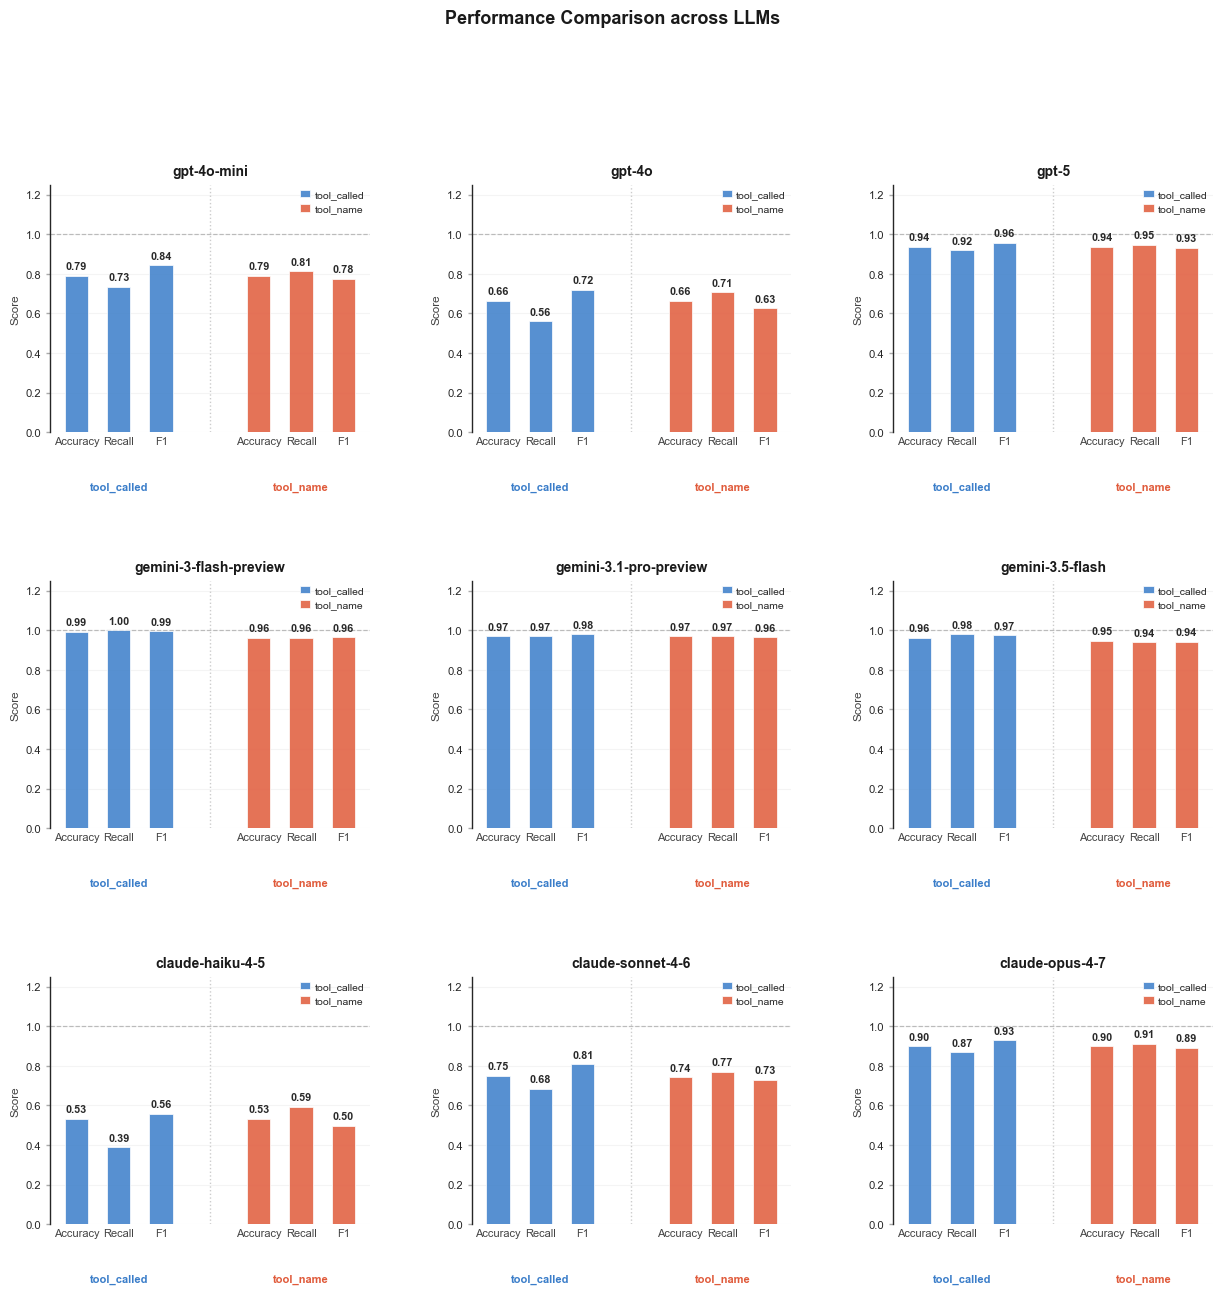

In [50]:
df_result = pd.read_csv('./tool_execution_test_Dataset/model_evaluation_result.csv')

y_true_tc = df_result['tool_called'].tolist()
y_true_tn = df_result['tool_name'].tolist()

def calc_metrics(y_true, y_pred, task='binary'):
    pairs = [(t, p) for t, p in zip(y_true, y_pred)
             if p is not None and str(p) != 'nan']
    if not pairs:
        return {'accuracy': None, 'recall': None, 'f1': None}
    yt, yp = zip(*pairs)
    if task == 'binary':
        return {
            'accuracy': accuracy_score(yt, yp),
            'recall':   recall_score(yt, yp, zero_division=0),
            'f1':       f1_score(yt, yp, zero_division=0),
        }
    else:
        return {
            'accuracy': accuracy_score(yt, yp),
            'recall':   recall_score(yt, yp, average='macro', zero_division=0),
            'f1':       f1_score(yt, yp, average='macro', zero_division=0),
        }

all_model_names = [c.replace('_tool_called', '') for c in df_result.columns if c.endswith('_tool_called')]

metrics_tc, metrics_tn = {}, {}
for m in all_model_names:
    metrics_tc[m] = calc_metrics(y_true_tc, df_result[f'{m}_tool_called'].tolist(), 'binary')
    metrics_tn[m] = calc_metrics(y_true_tn, df_result[f'{m}_tool_name'].tolist(),   'multiclass')

print("=== tool_called (binary) ===")
print(pd.DataFrame(metrics_tc).T.round(4).to_string())
print("\n=== tool_name (macro) ===")
print(pd.DataFrame(metrics_tn).T.round(4).to_string())

# ── 스타일 설정 (논문용) ──────────────────────────────────────────────────────
sns.set_theme(style='ticks', context='paper', font_scale=1.1)
plt.rcParams.update({
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'axes.grid.axis':    'y',
    'grid.color':        '#EBEBEB',
    'grid.linewidth':    0.8,
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
})

COLOR_TC = '#3A7DC9'
COLOR_TN = '#E05A3A'

metric_keys   = ['accuracy', 'recall', 'f1']
metric_labels = ['Accuracy', 'Recall', 'F1']
width = 0.55
gap   = 1.3
x_tc  = np.array([0, 1, 2], dtype=float)
x_tn  = x_tc + len(metric_keys) + gap

n     = len(all_model_names)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.5 * nrows),
                         gridspec_kw={'hspace': 0.6, 'wspace': 0.32})
fig.suptitle('Performance Comparison across LLMs',
             fontsize=13, fontweight='bold', y=1.01, color='#1A1A1A')

axes_flat = axes.flatten()

for i, model_name in enumerate(all_model_names):
    ax = axes_flat[i]
    ax.set_axisbelow(True)

    vals_tc = [metrics_tc[model_name][k] or 0 for k in metric_keys]
    vals_tn = [metrics_tn[model_name][k] or 0 for k in metric_keys]

    bars_tc = ax.bar(x_tc, vals_tc, width, color=COLOR_TC, alpha=0.85,
                     edgecolor='white', linewidth=0.6, label='tool_called', zorder=3)
    bars_tn = ax.bar(x_tn, vals_tn, width, color=COLOR_TN, alpha=0.85,
                     edgecolor='white', linewidth=0.6, label='tool_name',   zorder=3)

    for bar, v in zip(list(bars_tc) + list(bars_tn), vals_tc + vals_tn):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.022,
                f'{v:.2f}', ha='center', va='bottom',
                fontsize=7.8, fontweight='bold', color='#2A2A2A')

    ax.set_xticks(np.concatenate([x_tc, x_tn]))
    ax.set_xticklabels(metric_labels * 2, fontsize=8, color='#444444')
    ax.set_ylim(0, 1.25)
    ax.set_ylabel('Score', fontsize=8.5, color='#444444')
    ax.tick_params(axis='x', length=0, pad=3)
    ax.tick_params(axis='y', labelsize=8, color='#AAAAAA', length=3)
    ax.axhline(y=1.0, color='#BBBBBB', linestyle='--', linewidth=0.85, zorder=2)

    # 그룹 구분 점선
    mid_gap = (x_tc[-1] + x_tn[0]) / 2
    ax.axvline(x=mid_gap, color='#CCCCCC', linestyle=':', linewidth=1.0, zorder=1)

    # 그룹 레이블
    ax.text(x_tc.mean(), -0.20, 'tool_called', ha='center', va='top',
            fontsize=8, color=COLOR_TC, fontweight='bold',
            transform=ax.get_xaxis_transform())
    ax.text(x_tn.mean(), -0.20, 'tool_name', ha='center', va='top',
            fontsize=8, color=COLOR_TN, fontweight='bold',
            transform=ax.get_xaxis_transform())

    ax.set_title(model_name, fontsize=10, fontweight='bold',
                 color='#1A1A1A', pad=7)
    ax.legend(fontsize=7.5, frameon=False, loc='upper right',
              handlelength=1.0, handletextpad=0.4, borderpad=0)

    sns.despine(ax=ax, bottom=True)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.savefig('./tool_execution_test_Dataset/metrics_comparison.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# LLM-as-a-Judge — Query 품질 평가

In [12]:
df_result = pd.read_csv('./tool_execution_test_Dataset/model_evaluation_result.csv')

In [13]:
JUDGE_SYSTEM_PROMPT = """당신은 검색 쿼리 품질 평가 전문가입니다.
아래는 PPT 슬라이드 내용과 해당 슬라이드에 대한 정답 검색 쿼리, 그리고 평가 대상 쿼리입니다.
정답 쿼리를 참고하여 평가 대상 쿼리의 품질을 1~5점으로 평가하세요.

# 채점 기준
1점: 슬라이드 내용과 무관하거나 완전히 잘못된 키워드를 사용한 쿼리. 검색 시 관련 결과가 나올 가능성이 거의 없음.
2점: 관련 키워드를 일부 포함하나 핵심 주제를 벗어났거나, 불필요한 단어가 많아 검색 노이즈가 발생할 수 있음.
3점: 핵심 키워드를 포함하지만 범위가 너무 넓거나 좁음. 또는 검색어가 지나치게 길어 간결성이 부족함.
4점: 핵심 키워드를 잘 포함하고 간결하며 검색에 효과적. 정답 쿼리와 의미적으로 유사한 수준.
5점: 정답 쿼리와 동일하거나 그보다 더 정확하고 간결한 최적의 쿼리. 검색 결과의 품질이 충분히 보장됨.

# 출력 형식
반드시 아래 JSON만 출력하세요. 다른 텍스트는 절대 출력하지 마세요.
{"score": 1~5 정수, "reason": "한 문장 평가 이유"}"""

judge_llm = ChatOpenAI(model="gpt-4o", temperature=0)

def judge_query(content: str, gt_query: str, pred_query, tool_name: str) -> dict:
    if pred_query is None or str(pred_query).strip() in ('', 'nan', 'None'):
        return {"score": None, "reason": "query 없음 (검색 미실행 또는 오류)"}

    user_msg = f"""[슬라이드 내용]
{content}

[정답 쿼리] (tool: {tool_name})
{gt_query}

[평가 대상 쿼리]
{pred_query}"""

    try:
        response = judge_llm.invoke([
            SystemMessage(content=JUDGE_SYSTEM_PROMPT),
            HumanMessage(content=user_msg)
        ])
        text = response.content.strip()
        if text.startswith("```"):
            text = text.split("```")[1]
            if text.startswith("json"):
                text = text[4:]
        return json.loads(text.strip())
    except json.JSONDecodeError:
        return {"score": None, "reason": f"JSON 파싱 실패: {response.content[:100]}"}
    except Exception as e:
        return {"score": None, "reason": f"오류: {str(e)}"}

print("Judge 준비 완료 (gpt-4o, 1~5점 척도)")

Judge 준비 완료 (gpt-4o, 1~5점 척도)


In [22]:
MODEL_NAMES = ['gpt-5', 'gemini-3.1-pro-preview', 'gemini-3.5-flash', 'gemini-3-flash-preview', 'claude-opus-4-7',  'claude-sonnet-4-6',  'claude-haiku-4-5']

In [23]:
JUDGE_CSV = './tool_execution_test_Dataset/model_evaluation_result.csv'

df_search = df_result[df_result['tool_called'] == True].copy()
print(f"Query 평가 대상: {len(df_search)}행 (tool_called=True)\n")

for model_name in MODEL_NAMES:
    col_q      = f"{model_name}_query"
    col_score  = f"{model_name}_query_score"
    col_reason = f"{model_name}_query_reason"

    # ── 재개 위치 확인 ─────────────────────────────────────────────────────────
    if col_score in df_result.columns:
        scored_mask = df_result.loc[df_search.index, col_score].notna()
        if scored_mask.all():
            print(f"⏭  {model_name}: 완료 — 건너뜀")
            continue
        start_i = int(scored_mask.sum())
        scores  = df_result.loc[df_search.index[:start_i], col_score].tolist()
        reasons = df_result.loc[df_search.index[:start_i], col_reason].tolist()
        print(f"\n{'='*60}")
        print(f"🔄 {model_name}: {start_i}행부터 재개")
        print(f"{'='*60}")
    else:
        start_i = 0
        scores, reasons = [], []
        print(f"\n{'='*60}")
        print(f"▶  {model_name}: 처음부터 시작")
        print(f"{'='*60}")

    for i, (idx, row) in enumerate(df_search.iloc[start_i:].iterrows(), start=start_i):
        res = judge_query(
            content    = row['content'],
            gt_query   = row['query'],
            pred_query = row[col_q],
            tool_name  = row['tool_name']
        )
        score = res.get('score')
        scores.append(score if score is not None else np.nan)
        reasons.append(res.get('reason'))
        print(f"  [{i+1:3d}/{len(df_search)}] score={score}  {res.get('reason', '')[:60]}")

        # 10행마다 중간 저장
        if (i + 1) % 10 == 0:
            df_result.loc[df_search.index[:i+1], col_score]  = scores
            df_result.loc[df_search.index[:i+1], col_reason] = reasons
            df_result.to_csv(JUDGE_CSV, index=False, encoding='utf-8-sig')
            print(f"  💾 {i+1}행 저장 → {JUDGE_CSV}")

    df_result.loc[df_search.index, col_score]  = scores
    df_result.loc[df_search.index, col_reason] = reasons
    print(f"  ✅ 완료\n")

df_result.to_csv(JUDGE_CSV, index=False, encoding='utf-8-sig')
print("저장 완료 (query 점수 포함) → model_evaluation_result.csv")

Query 평가 대상: 98행 (tool_called=True)


🔄 gpt-5: 10행부터 재개
  [ 11/98] score=2  쿼리가 Agados와 관련이 있지만, 'UI software'는 슬라이드의 핵심 주제인 'Smart Arch
  [ 12/98] score=4  핵심 키워드인 'Agados Smart Client'를 포함하여 슬라이드의 주요 내용을 잘 반영하고 있어 검
  [ 13/98] score=2  쿼리가 Agados와 관련이 있지만, 'UI software Korea'는 슬라이드의 핵심 주제와 관련이 적
  [ 14/98] score=2  쿼리가 관련 키워드를 일부 포함하지만, 'UI software'는 슬라이드의 핵심 주제인 'Biz Appli
  [ 15/98] score=3  쿼리가 Agados와 관련된 소프트웨어를 언급하고 있지만, 'UI'라는 키워드는 슬라이드의 핵심 주제와 직접
  [ 16/98] score=2  쿼리가 관련 키워드를 일부 포함하지만, 핵심 주제인 'Smart Client Publishing'과는 거리가
  [ 17/98] score=4  핵심 키워드를 잘 포함하고 있으며, 검색에 효과적이지만 'Biz Application'이라는 구체적인 부분이
  [ 18/98] score=2  쿼리가 Agados와 관련된 키워드를 포함하고 있으나, 슬라이드의 핵심 주제인 Biz Application의
  [ 19/98] score=None  query 없음 (검색 미실행 또는 오류)
  [ 20/98] score=3  쿼리가 Agados와 관련된 소프트웨어 구성 도구를 언급하여 관련성이 있지만, 슬라이드의 핵심 주제인 'ap
  💾 20행 저장 → ./tool_execution_test_Dataset/model_evaluation_result.csv
  [ 21/98] score=3  핵심 키워드인 'Agados'를 포함하고 있지만, 'software Korea'는 슬라이드의 기술적 혜택과 
  [ 22/98] score

In [28]:
# Judge 평가할 모델 지정 (MODEL_NAMES 중 원하는 것만 선택)
MODEL_NAMES = [
    'gpt-4o-mini',
    'gpt-4o',
    'gpt-5',
    'gemini-3-flash-preview',
    'gemini-3.1-pro-preview',
    'gemini-3.5-flash',
    'claude-haiku-4-5',
    'claude-sonnet-4-6',
    'claude-opus-4-7',
]

=== LLM별 Query 평균 점수 (미검색=1점) ===
  gpt-4o-mini                   : 3.469
  gpt-4o                        : 2.959
  gpt-5                         : 3.816
  gemini-3-flash-preview        : 4.143
  gemini-3.1-pro-preview        : 4.071
  gemini-3.5-flash              : 4.061
  claude-haiku-4-5              : 2.224
  claude-sonnet-4-6             : 3.194
  claude-opus-4-7               : 3.867

=== 점수 분포 (개수, 미검색=1점) ===
  모델                                1점    2점    3점    4점    5점
  ----------------------------------------------------------
  gpt-4o-mini                       26     2     5    30    35
  gpt-4o                            43     2     1    20    32
  gpt-5                              8     8    10    40    32
  gemini-3-flash-preview             2     1     7    59    29
  gemini-3.1-pro-preview             5     0    14    43    36
  gemini-3.5-flash                   6     2    11    40    39
  claude-haiku-4-5                  60     0     3    26     9
  claude-sonn

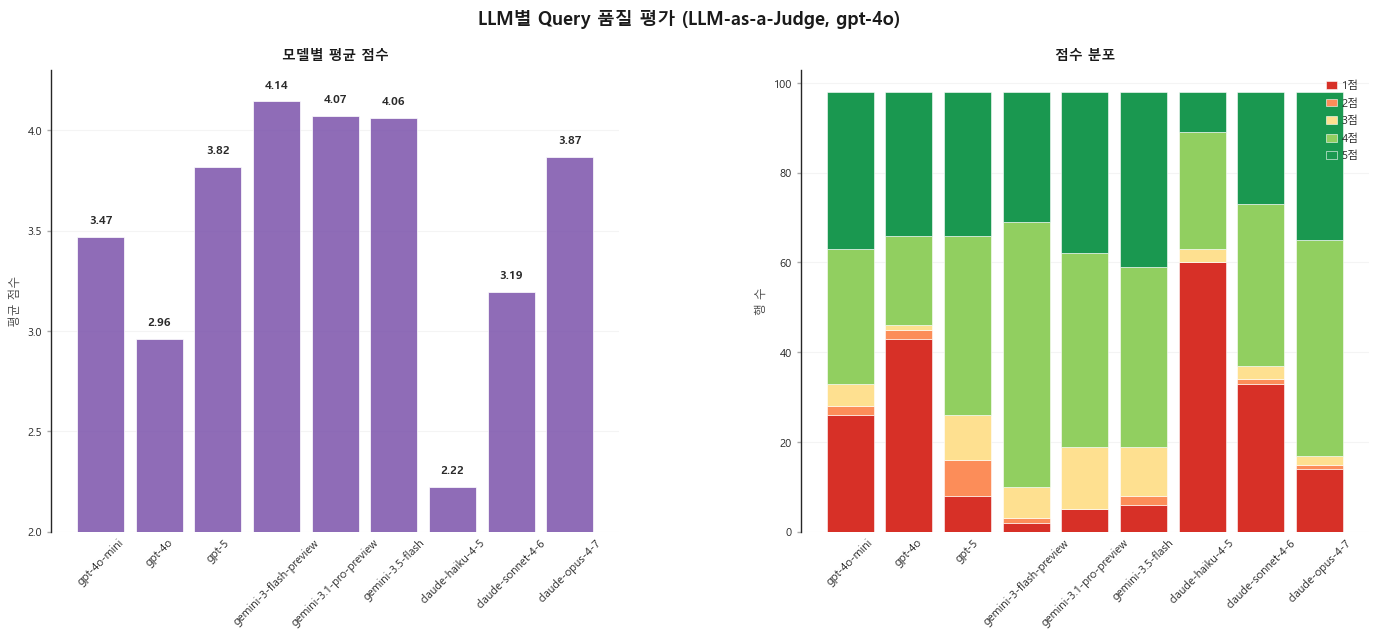

In [55]:
df_result = pd.read_csv('./tool_execution_test_Dataset/model_evaluation_result.csv')

model_labels = MODEL_NAMES

# tool_called=True인 행 인덱스만 사용
tc_true_idx = df_result[df_result['tool_called'] == True].index

# ── 모델별 평균 점수 ────────────────────────────────────────────────────────────
avg_scores = {}
score_dists = {}
for m in MODEL_NAMES:
    col = f"{m}_query_score"
    scores = pd.to_numeric(df_result.loc[tc_true_idx, col], errors='coerce').fillna(1)
    avg_scores[m] = scores.mean() if len(scores) > 0 else 0
    score_dists[m] = scores.value_counts().reindex([1, 2, 3, 4, 5], fill_value=0)

print("=== LLM별 Query 평균 점수 (미검색=1점) ===")
for m, s in avg_scores.items():
    print(f"  {m:30s}: {s:.3f}")

print("\n=== 점수 분포 (개수, 미검색=1점) ===")
print(f"  {'모델':30s}  {'1점':>4}  {'2점':>4}  {'3점':>4}  {'4점':>4}  {'5점':>4}")
print("  " + "-" * 58)
for m in MODEL_NAMES:
    d = score_dists[m]
    print(f"  {m:30s}  {int(d[1]):>4}  {int(d[2]):>4}  {int(d[3]):>4}  {int(d[4]):>4}  {int(d[5]):>4}")

# ── 스타일 설정 ───────────────────────────────────────────────────────────────
sns.set_theme(style='ticks', context='paper', font_scale=1.1)
plt.rcParams.update({
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'axes.grid.axis':    'y',
    'grid.color':        '#EBEBEB',
    'grid.linewidth':    0.8,
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'font.family':       'Malgun Gothic',
    'axes.unicode_minus': False,
})

COLOR_AVG    = '#7B52AB'
SCORE_COLORS = ['#d73027', '#fc8d59', '#fee090', '#91cf60', '#1a9850']

fig, axes = plt.subplots(1, 2, figsize=(17, 6), gridspec_kw={'wspace': 0.32})
fig.suptitle('LLM별 Query 품질 평가 (LLM-as-a-Judge, gpt-4o)',
             fontsize=13, fontweight='bold', color='#1A1A1A')

ax = axes[0]
ax.set_axisbelow(True)
vals = [avg_scores[m] for m in MODEL_NAMES]
bars = ax.bar(model_labels, vals, color=COLOR_AVG, alpha=0.85,
              edgecolor='white', linewidth=0.6, zorder=3)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f'{v:.2f}', ha='center', va='bottom',
            fontsize=8.5, fontweight='bold', color='#2A2A2A')
ax.axhline(y=5, color='#BBBBBB', linestyle='--', linewidth=0.85, zorder=2)
ax.set_title('모델별 평균 점수', fontsize=10, fontweight='bold', color='#1A1A1A', pad=7)
ax.set_ylim(2.0, 4.3)
ax.set_ylabel('평균 점수', fontsize=8.5, color='#444444')
ax.tick_params(axis='x', rotation=45, labelsize=8, length=0)
ax.tick_params(axis='y', labelsize=8, color='#AAAAAA', length=3)
sns.despine(ax=ax, bottom=True)

ax = axes[1]
ax.set_axisbelow(True)
bottom = np.zeros(len(MODEL_NAMES))
for score_val, color in zip([1, 2, 3, 4, 5], SCORE_COLORS):
    heights = [score_dists[m][score_val] for m in MODEL_NAMES]
    ax.bar(model_labels, heights, bottom=bottom, label=f'{score_val}점',
           color=color, edgecolor='white', linewidth=0.4, zorder=3)
    bottom += np.array(heights)
ax.set_title('점수 분포', fontsize=10, fontweight='bold', color='#1A1A1A', pad=7)
ax.set_ylabel('행 수', fontsize=8.5, color='#444444')
ax.tick_params(axis='x', rotation=45, labelsize=8, length=0)
ax.tick_params(axis='y', labelsize=8, color='#AAAAAA', length=3)
ax.legend(loc='upper right', fontsize=8, frameon=False,
          handlelength=1.0, handletextpad=0.4)
sns.despine(ax=ax, bottom=True)

plt.savefig('./tool_execution_test_Dataset/query_score_comparison.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
# ── 평균: score 있는 행만 / 분포: 비율(%) ────────────────────────────────────
avg_scores_v2 = {}
score_dists_v2 = {}
for m in MODEL_NAMES:
    col = f"{m}_query_score"
    scores = pd.to_numeric(df_result.loc[tc_true_idx, col], errors='coerce').dropna()
    avg_scores_v2[m] = scores.mean() if len(scores) > 0 else 0
    total = len(scores) if len(scores) > 0 else 1
    score_dists_v2[m] = scores.value_counts().reindex([1, 2, 3, 4, 5], fill_value=0) / total * 100

print("=== LLM별 Query 평균 점수 (score 있는 행만) ===")
for m, s in avg_scores_v2.items():
    print(f"  {m:30s}: {s:.3f}")

print("\n=== 점수 분포 (비율, score 있는 행만) ===")
print(f"  {'모델':30s}  {'1점':>6}  {'2점':>6}  {'3점':>6}  {'4점':>6}  {'5점':>6}")
print("  " + "-" * 66)
for m in MODEL_NAMES:
    d = score_dists_v2[m]
    print(f"  {m:30s}  {d[1]:>5.1f}%  {d[2]:>5.1f}%  {d[3]:>5.1f}%  {d[4]:>5.1f}%  {d[5]:>5.1f}%")

# ── 스타일 설정 ───────────────────────────────────────────────────────────────
sns.set_theme(style='ticks', context='paper', font_scale=1.1)
plt.rcParams.update({
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'axes.grid.axis':     'y',
    'grid.color':         '#EBEBEB',
    'grid.linewidth':     0.8,
    'figure.facecolor':   'white',
    'axes.facecolor':     'white',
    'font.family':        'Malgun Gothic',
    'axes.unicode_minus': False,
})

COLOR_AVG    = '#7B52AB'
SCORE_COLORS = ['#d73027', '#fc8d59', '#fee090', '#91cf60', '#1a9850']

fig, axes = plt.subplots(1, 2, figsize=(17, 6), gridspec_kw={'wspace': 0.32})
fig.suptitle('LLM별 Query 품질 평가 (LLM-as-a-Judge, gpt-4o)',
             fontsize=13, fontweight='bold', color='#1A1A1A')

ax = axes[0]
ax.set_axisbelow(True)
vals = [avg_scores_v2[m] for m in MODEL_NAMES]
bars = ax.bar(model_labels, vals, color=COLOR_AVG, alpha=0.85,
              edgecolor='white', linewidth=0.6, zorder=3)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f'{v:.2f}', ha='center', va='bottom',
            fontsize=8.5, fontweight='bold', color='#2A2A2A')
ax.axhline(y=5, color='#BBBBBB', linestyle='--', linewidth=0.85, zorder=2)
ax.set_title('모델별 평균 점수 (score 있는 행만)',
             fontsize=10, fontweight='bold', color='#1A1A1A', pad=7)
ax.set_ylim(0, 6.0)
ax.set_ylabel('평균 점수', fontsize=8.5, color='#444444')
ax.tick_params(axis='x', rotation=45, labelsize=8, length=0)
ax.tick_params(axis='y', labelsize=8, color='#AAAAAA', length=3)
sns.despine(ax=ax, bottom=True)

ax = axes[1]
ax.set_axisbelow(True)
bottom = np.zeros(len(MODEL_NAMES))
for score_val, color in zip([1, 2, 3, 4, 5], SCORE_COLORS):
    heights = [score_dists_v2[m][score_val] for m in MODEL_NAMES]
    ax.bar(model_labels, heights, bottom=bottom, label=f'{score_val}점',
           color=color, edgecolor='white', linewidth=0.4, zorder=3)
    bottom += np.array(heights)
ax.set_title('점수 분포 (비율, score 있는 행만)',
             fontsize=10, fontweight='bold', color='#1A1A1A', pad=7)
ax.set_ylabel('비율 (%)', fontsize=8.5, color='#444444')
ax.set_ylim(0, 115)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.tick_params(axis='x', rotation=45, labelsize=8, length=0)
ax.tick_params(axis='y', labelsize=8, color='#AAAAAA', length=3)
ax.legend(loc='upper right', fontsize=8, frameon=False,
          handlelength=1.0, handletextpad=0.4)
sns.despine(ax=ax, bottom=True)

plt.savefig('./tool_execution_test_Dataset/query_score_comparison_ratio.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()